# TS6 - Transformada Z y Respuesta en Frecuencia

## Objetivos

En esta tarea se analizan distintos sistemas discretos representados mediante ecuaciones en diferencias.

Para cada sistema se calcula:

1. La función de transferencia \(T(z)=\frac{Y(z)}{X(z)}\) mediante Transformada Z.
2. La respuesta en frecuencia \(T(e^{j\omega})\).
3. El módulo y la fase de la respuesta en frecuencia.
4. La validación numérica mediante Python utilizando la función `freqz()` de Scipy.

Además, se adjunta el desarrollo analítico realizado manualmente para cada uno de los ejercicios.

# Desarrollo analítico

A continuación se adjunta el desarrollo realizado a mano para la obtención de las funciones de transferencia y sus correspondientes respuestas en frecuencia. Luego se procede con la verificación de los resultados en Python

## Desarrollo realizado a mano

Ver archivo adjunto:

**TS6_260612_093715.pdf**

In [8]:
from IPython.display import IFrame

IFrame("TS6_260612_093715.pdf",
       width=900,
       height=700)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

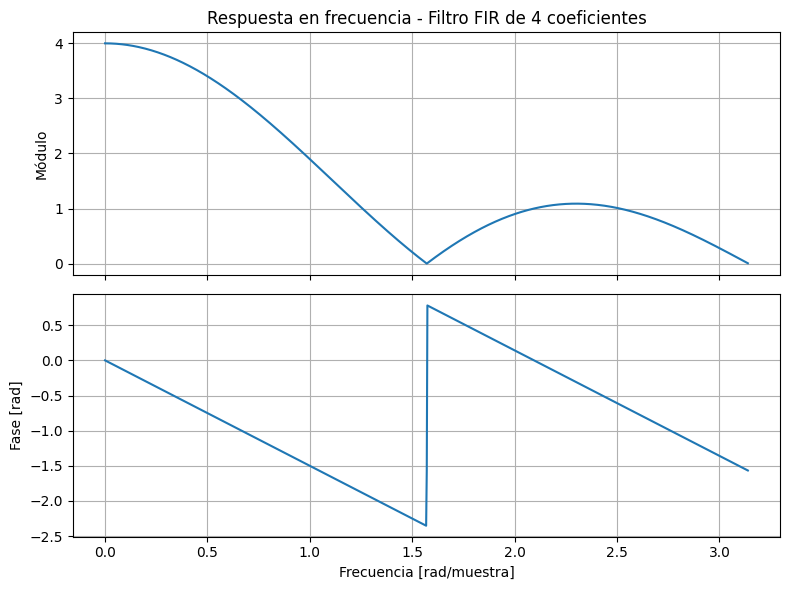

In [2]:
# ITEM a

b_coeff = np.array([1, 1, 1, 1])
a_coeff = np.array([1, 0, 0, 0])

taps = b_coeff.shape[0]

omega, resp_freq = sig.freqz(b_coeff,
                             a=a_coeff,
                             worN=1024)

fig, axs = plt.subplots(2, 1,
                        sharex=True,
                        figsize=(8,6),
                        tight_layout=True)

ax1, ax2 = axs

ax1.set_title(f"Respuesta en frecuencia - Filtro FIR de {taps} coeficientes")
ax1.plot(omega, np.abs(resp_freq))
ax1.set_ylabel("Módulo")
ax1.grid()

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase)
ax2.set_ylabel("Fase [rad]")
ax2.set_xlabel("Frecuencia [rad/muestra]")
ax2.grid()

plt.show()

## Análisis a

Se observa una respuesta típica de un filtro de media móvil de cuatro muestras.

El módulo presenta máximos en bajas frecuencias y nulos periódicos sobre el eje de frecuencias. La fase resulta aproximadamente lineal debido a la simetría de los coeficientes del filtro, característica propia de los filtros FIR de fase lineal.

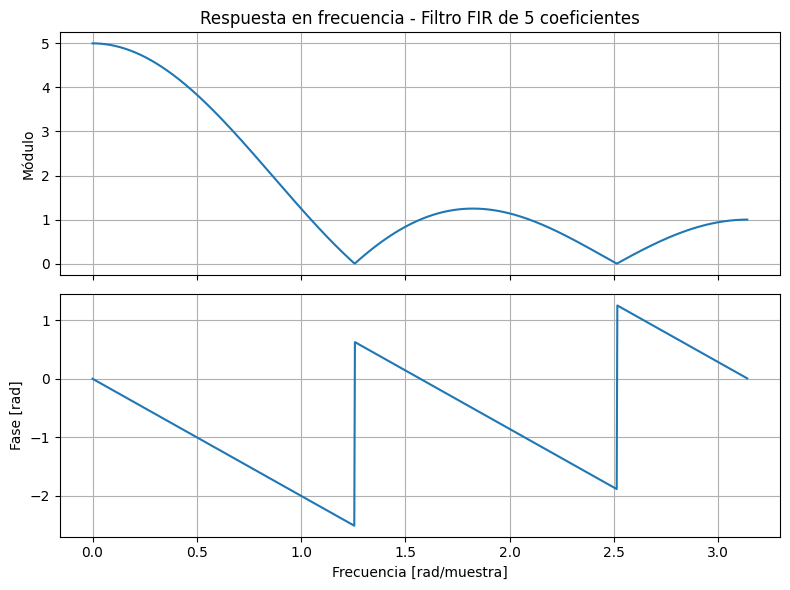

In [4]:
# ITEM b

b_coeff = np.array([1, 1, 1, 1, 1])
a_coeff = np.array([1, 0, 0, 0, 0])

taps = b_coeff.shape[0]

omega, resp_freq = sig.freqz(b_coeff,
                             a=a_coeff,
                             worN=1024)

fig, axs = plt.subplots(2, 1,
                        sharex=True,
                        figsize=(8,6),
                        tight_layout=True)

ax1, ax2 = axs

ax1.set_title(f"Respuesta en frecuencia - Filtro FIR de {taps} coeficientes")
ax1.plot(omega, np.abs(resp_freq))
ax1.set_ylabel("Módulo")
ax1.grid()

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase)
ax2.set_ylabel("Fase [rad]")
ax2.set_xlabel("Frecuencia [rad/muestra]")
ax2.grid()

plt.show()

## Análisis b

Al aumentar la cantidad de coeficientes del promedio móvil se incrementa la selectividad del filtro.

Se observan lóbulos principales más angostos y una mayor cantidad de nulos en la respuesta en frecuencia. La fase continúa siendo lineal debido a la simetría de los coeficientes.

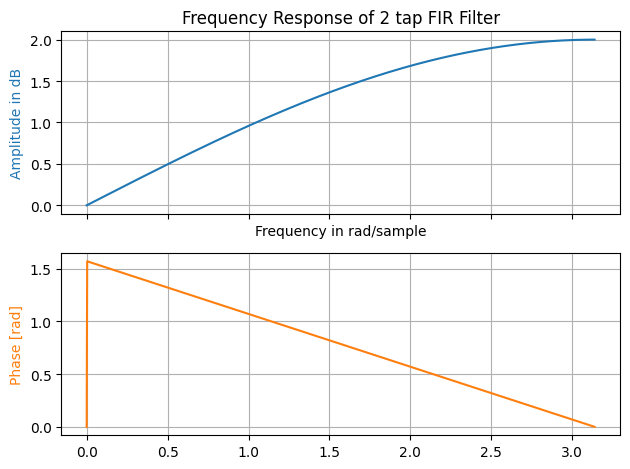

In [5]:
#%% ITEM c
# T(z) = (z - 1) / (z)

b_coeff = np.array([1, -1])
a_coeff = np.array([1, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff.shape[0]

omega, resp_freq = sig.freqz(b_coeff, a = a_coeff, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap FIR Filter") # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega, abs(resp_freq), 'C0')
# ax1.plot(omega, abs(resp_freq), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

# ax2 = ax1.twinx()

phase = np.unwrap(np.angle(resp_freq)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase
# phase = np.angle(resp_freq)

ax2.plot(omega, phase, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

## Análisis c

Este sistema implementa una diferencia entre muestras consecutivas, comportándose como un filtro pasaaltos.

Se observa una atenuación completa en continua y una ganancia creciente a medida que aumenta la frecuencia.

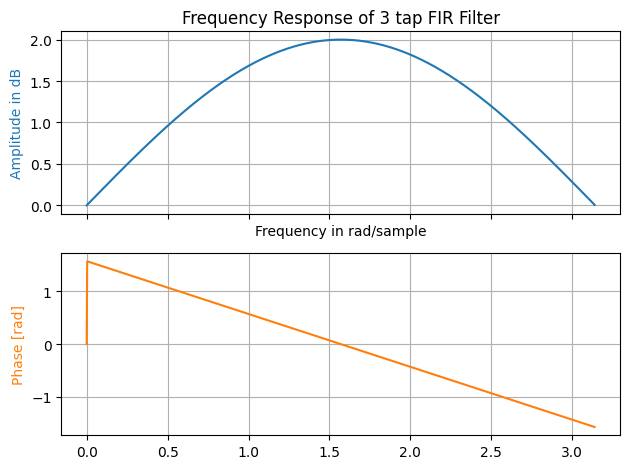

In [7]:
#%% ITEM d
# T(z) = (z^2 - 1) / (z^2)

b_coeff = np.array([1, 0, -1])
a_coeff = np.array([1, 0, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff.shape[0]

omega, resp_freq = sig.freqz(b_coeff, a = a_coeff, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap FIR Filter") # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega, abs(resp_freq), 'C0')
# ax1.plot(omega, abs(resp_freq), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

# ax2 = ax1.twinx()

phase = np.unwrap(np.angle(resp_freq)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase
# phase = np.angle(resp_freq)

ax2.plot(omega, phase, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

## Análisis d

Al utilizar una diferencia de dos muestras separadas por un retardo de dos períodos, la respuesta en frecuencia presenta nulos tanto en continua como en la frecuencia de Nyquist.

Esto genera una respuesta característica con comportamiento pasa banda, donde la máxima respuesta se encuentra en frecuencias intermedias.

# Conclusiones

Se verificó mediante simulación numérica la respuesta en frecuencia obtenida analíticamente a partir de la Transformada Z.

Los filtros de media móvil (a y b) presentan comportamiento pasabajos y fase lineal debido a la simetría de sus coeficientes.

Los sistemas diferenciales (c y d) eliminan la componente continua y realzan las componentes de mayor frecuencia, comportándose como filtros pasaaltos o pasa banda según la estructura utilizada.

La comparación entre los resultados teóricos y los obtenidos con `scipy.signal.freqz()` mostró una coincidencia completa, validando el desarrollo analítico realizado.